# FigSI HeLa gDNA CpG cutoff curve
Yanbo Xu \
2026-06-26

Saturation curve reference https://genome.cshlp.org/content/31/7/1280.long Fig.4B. Y-axis is covered CpGs, X-axis is depth. 

Run `count_CpG_depth.sh` first to get covered CpGs under 1x to 20x depth, which is accumulated across all CpGs.

* 10 pg - 10x, 100 pg - 15x, 1 ng - 20x

In [1]:
import os
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Patch
from pathlib import Path
from matplotlib import colors as mcolors

fig_dir=Path("/home/xuyanbo/project/MOF_TAPS/analysis/fig_factory/fig/FigSI/hela_cpg_cutoff_curve")

In [2]:
font_path = "/home/xuyanbo/ARIAL.TTF"
fm.fontManager.addfont(font_path)

prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()
print(font_name)

Arial


In [3]:
mpl.rcParams["font.family"] = font_name
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

mpl.rcParams["font.size"] = 10
mpl.rcParams["axes.titlesize"] = 10
mpl.rcParams["legend.fontsize"] = 10

mpl.rcParams["figure.dpi"] = 300

mpl.rcParams["axes.linewidth"] = 0.8
mpl.rcParams["lines.linewidth"] = 0.8

In [4]:
groups = {
    "MOF-TAPS": ["fym260124_S06", "fym260124_S05", "fym260124_S04"],
    "TAPS+":    ["fym260106_S06", "fym260106_S05", "fym260106_S04"],
    "TAPS":     ["fym260106_S03", "fym260106_S02", "fym260106_S01"],
}

input_order = ["1 ng", "100 pg", "10 pg"]

rows = []
for method, sample_list in groups.items():
    for sample, input in zip(sample_list, input_order):
        rows.append({
            "sample": sample,
            "method": method,
            "input": input
        })

sample_info = pd.DataFrame(rows)
sample_info

,sample,method,input
0,fym260124_S06,MOF-TAPS,1 ng
1,fym260124_S05,MOF-TAPS,100 pg
2,fym260124_S04,MOF-TAPS,10 pg
3,fym260106_S06,TAPS+,1 ng
4,fym260106_S05,TAPS+,100 pg
5,fym260106_S04,TAPS+,10 pg
6,fym260106_S03,TAPS,1 ng
7,fym260106_S02,TAPS,100 pg
8,fym260106_S01,TAPS,10 pg


In [5]:
all_dfs = []

for sample in sample_info["sample"]:
    
    file_path = (
        fig_dir
        / f"{sample}.cpg_depth_1_20x.tsv"
    )
    
    tmp = pd.read_csv(file_path, sep="\t", header=None, names=["sample", "min_depth", "n_cpg"])
    all_dfs.append(tmp)

curve_df = pd.concat(all_dfs, ignore_index=True)

df = curve_df.merge(sample_info, on="sample", how="left")
df

,sample,min_depth,n_cpg,method,input
0,fym260124_S06,1,27342774,MOF-TAPS,1 ng
1,fym260124_S06,2,25750325,MOF-TAPS,1 ng
2,fym260124_S06,3,23035273,MOF-TAPS,1 ng
3,fym260124_S06,4,19364434,MOF-TAPS,1 ng
4,fym260124_S06,5,15256128,MOF-TAPS,1 ng
...,...,...,...,...,...
175,fym260106_S01,16,7148,TAPS,10 pg
176,fym260106_S01,17,6961,TAPS,10 pg
177,fym260106_S01,18,6764,TAPS,10 pg
178,fym260106_S01,19,6629,TAPS,10 pg


In [6]:
method_colors = {
    "MOF-TAPS": "#E59A2F",
    "TAPS": "#63B34C",
    "TAPS+": "#3B82C4",
}

method_order = [ "MOF-TAPS", "TAPS", "TAPS+"]

In [7]:
xmax_map = {
    "10 pg": 10,
    "100 pg": 15,
    "1 ng": 20
}

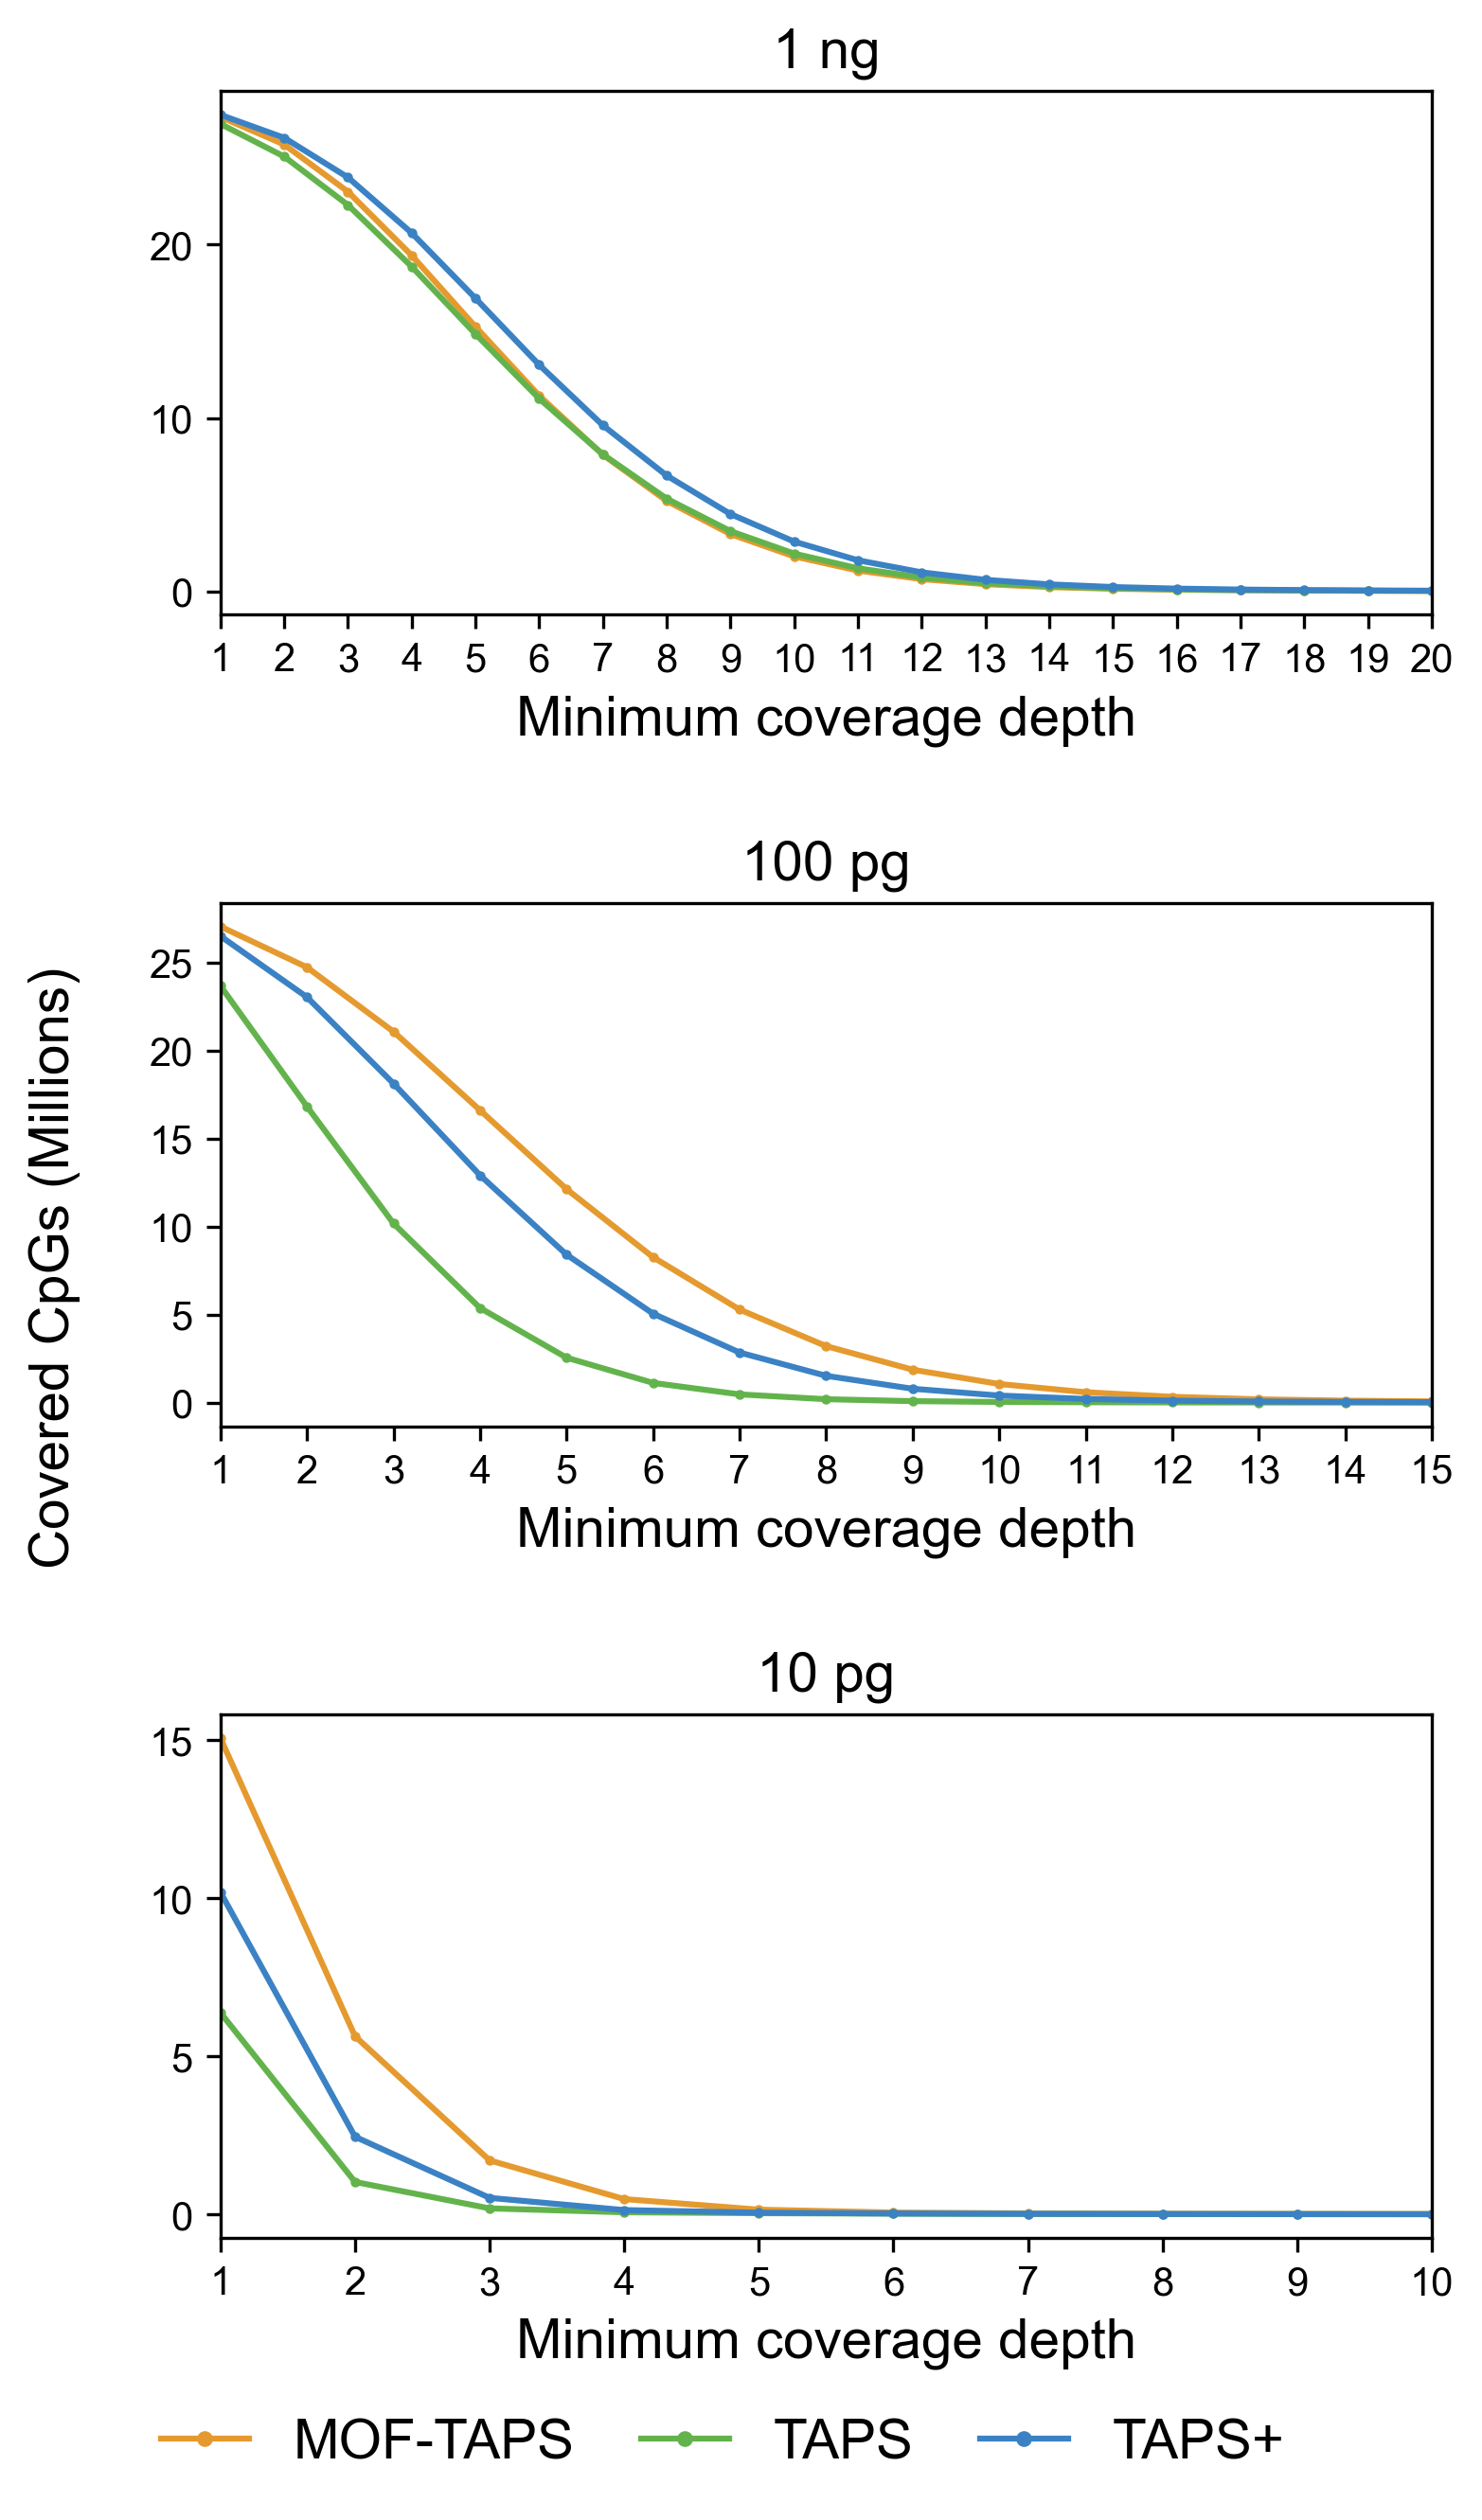

In [8]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(
    3, 1,
    figsize=(5.2, 9.0),
    sharey=False
)

for ax, input in zip(axes, input_order):
    sub = df[df["input"] == input].copy()
    xmax = xmax_map[input]
    sub = sub[sub["min_depth"] <= xmax].copy()

    for method in method_order:
        subdf = sub[sub["method"] == method].sort_values("min_depth")
        if subdf.empty:
            continue

        ax.plot(
            subdf["min_depth"],
            subdf["n_cpg"] / 1e6,
            marker="o",
            linewidth=1.5,
            markersize=2.5,
            markeredgewidth=0,
            color=method_colors.get(method, "gray"),
        )

    ax.set_title(input, fontsize=14)
    ax.set_xlabel("Minimum coverage depth", fontsize=14)
    ax.set_xticks(range(1, xmax + 1))
    ax.set_xlim(1, xmax)
    ax.tick_params(axis="both", labelsize=10)

    yvals = sub["n_cpg"] / 1e6
    yrange = yvals.max() - yvals.min()
    if yrange == 0:
        yrange = yvals.max() * 0.05 if yvals.max() != 0 else 1

    ax.set_ylim(
        yvals.min() - 0.05 * yrange,
        yvals.max() + 0.05 * yrange
    )

fig.supylabel("Covered CpGs (Millions)", fontsize=14, x=0.03)

legend_handles = [
    Line2D(
        [0], [0],
        color=method_colors.get(method, "gray"),
        marker="o",
        linewidth=1.5,
        markersize=4,
        markeredgewidth=0,
        label=method
    )
    for method in method_order
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=len(method_order),
    frameon=False,
    fontsize=14,
    handlelength=1.6,
    columnspacing=1.2
)

fig.subplots_adjust(
    left=0.16,
    right=0.98,
    top=0.96,
    bottom=0.12,
    hspace=0.55
)

plt.savefig(
    f"{fig_dir}/coverage_curves_combined_2.pdf",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)
plt.show()